In [12]:
import yfinance as yf
import pandas as pd
import numpy as np

# **PROBABILITY ANALYSIS**

In [13]:
df = pd.read_csv("reversion_signals.csv", index_col=0, parse_dates=True)

In [14]:
df.tail()

,Ratio,Support,Resistance,norm_price,bounce_zone,touch_days_ago,avg_15d_at_touch,norm_avg,approach,signal_v1,block1_pass,block2_pass,final_signal
Date,,,,,,,,,,,,,
2026-08-03,0.592087,0.55,0.60,0.841731,rev res bounce,2.0,0.605502,1.110032,NaN,NaN,NaN,NaN,NaN
2026-08-04,0.600730,0.60,0.65,0.014591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-05,0.599582,0.55,0.60,0.991632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-06,0.598114,0.55,0.60,0.962274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-07,0.601152,0.60,0.65,0.023040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
probability_df = df[["Ratio","Support","Resistance","final_signal"]]
probability_df.tail()

,Ratio,Support,Resistance,final_signal
Date,,,,
2026-08-03,0.592087,0.55,0.60,NaN
2026-08-04,0.600730,0.60,0.65,NaN
2026-08-05,0.599582,0.55,0.60,NaN
2026-08-06,0.598114,0.55,0.60,NaN
2026-08-07,0.601152,0.60,0.65,NaN


In [16]:
probability_df[probability_df["final_signal"] == "reverting from support"].shape

(21, 4)

In [17]:
probability_df[probability_df["final_signal"] == "reverting from resistance"].shape

(15, 4)

In [18]:
results = []

for i in range(len(probability_df)):

    row = probability_df.iloc[i]
    signal = row["final_signal"]

    if signal not in ["reverting from support","reverting from resistance"]:
        continue

    # store entry info
    entry_date = probability_df.index[i]
    entry_price = row["Ratio"]

    if signal == "reverting from support":
        target = row["Resistance"]
        stop = row["Support"]

    if signal == "reverting from resistance":
            target = row["Support"]
            stop = row["Resistance"]

    for j in range(i+1, len(probability_df)):
         

        future_price = probability_df.iloc[j]["Ratio"]
        exit_date = probability_df.index[j]

        outcome = None

        # Support trade
        if signal == "reverting from support":

            if future_price >= target:
                outcome = "Target"
            elif future_price <= stop:
                outcome = "Stop"

        # Resistance trade
        if signal == "reverting from resistance":

            if future_price <= target:
                outcome = "Target"
            elif future_price >= stop:
                outcome = "Stop"


        if outcome is not None:
            results.append({
                "Entry Date": entry_date,
                "Entry Px": entry_price,
                "Signal": signal,
                "Exit Date": exit_date,
                "Exit Px": future_price,
                "Outcome": outcome,
                "Holding Days": j-i
            })

            break



In [19]:
results_df = pd.DataFrame(results)

In [20]:
results_df

,Entry Date,Entry Px,Signal,Exit Date,Exit Px,Outcome,Holding Days
0,2022-12-02,0.919541,reverting from support,2023-01-11,0.898196,Stop,27
1,2022-12-05,0.918462,reverting from support,2023-01-11,0.898196,Stop,26
2,2022-12-06,0.926765,reverting from support,2023-01-11,0.898196,Stop,25
3,2023-02-21,0.887370,reverting from resistance,2023-06-02,0.900263,Stop,70
4,2023-02-22,0.888536,reverting from resistance,2023-06-02,0.900263,Stop,69
5,2023-02-27,0.889719,reverting from resistance,2023-06-02,0.900263,Stop,66
6,2023-03-07,0.886669,reverting from resistance,2023-06-02,0.900263,Stop,60
7,2023-09-11,0.868341,reverting from resistance,2023-10-13,0.797645,Target,24
8,2023-10-18,0.812861,reverting from support,2024-02-15,0.792639,Stop,83
9,2023-10-19,0.813717,reverting from support,2024-02-15,0.792639,Stop,82


Removing repeating signals (consecutive)

In [21]:
results_df["Entry Date"] = pd.to_datetime(results_df["Entry Date"])

results_df["prev_date"] = results_df["Entry Date"].shift(1)

results_df["date_gap"] = (results_df["Entry Date"] - results_df["prev_date"]).dt.days

results_df["is_new_trade"] = results_df["date_gap"].isna() | (results_df["date_gap"] > 3)

results_df_deduped = results_df[results_df["is_new_trade"]]

results_df_deduped

,Entry Date,Entry Px,Signal,Exit Date,Exit Px,Outcome,Holding Days,prev_date,date_gap,is_new_trade
0,2022-12-02,0.919541,reverting from support,2023-01-11,0.898196,Stop,27,NaT,NaN,True
3,2023-02-21,0.887370,reverting from resistance,2023-06-02,0.900263,Stop,70,2022-12-06,77.0,True
5,2023-02-27,0.889719,reverting from resistance,2023-06-02,0.900263,Stop,66,2023-02-22,5.0,True
6,2023-03-07,0.886669,reverting from resistance,2023-06-02,0.900263,Stop,60,2023-02-27,8.0,True
7,2023-09-11,0.868341,reverting from resistance,2023-10-13,0.797645,Target,24,2023-03-07,188.0,True
8,2023-10-18,0.812861,reverting from support,2024-02-15,0.792639,Stop,83,2023-09-11,37.0,True
12,2023-11-22,0.812008,reverting from support,2024-02-15,0.792639,Stop,58,2023-10-23,30.0,True
15,2024-04-02,0.793880,reverting from resistance,2024-04-26,0.746896,Target,18,2023-11-24,130.0,True
18,2024-05-09,0.759018,reverting from support,2024-05-10,0.746166,Stop,1,2024-04-04,35.0,True
19,2024-10-08,0.606985,reverting from support,2024-10-22,0.659219,Target,10,2024-05-09,152.0,True


In [22]:
df = results_df_deduped.copy()

# 1. sign column: +1 for long (support), -1 for short (resistance)
df["sign"] = df["Signal"].map({"reverting from support": 1, "reverting from resistance": -1})

# 2. returns column
df["return_pct"] = df["sign"] * (df["Exit Px"] - df["Entry Px"]) / df["Entry Px"]

df.tail()

,Entry Date,Entry Px,Signal,Exit Date,Exit Px,Outcome,Holding Days,prev_date,date_gap,is_new_trade,sign,return_pct
23,2025-05-08,0.635602,reverting from resistance,2025-06-26,0.654126,Stop,35,2025-03-07,62.0,True,-1,-0.029144
26,2025-08-06,0.608876,reverting from support,2025-09-03,0.651231,Target,20,2025-05-12,86.0,True,1,0.069562
27,2025-10-02,0.660782,reverting from support,2025-11-24,0.703106,Target,37,2025-08-06,57.0,True,1,0.064052
29,2025-12-04,0.665371,reverting from support,2025-12-17,0.643671,Stop,9,2025-10-03,62.0,True,1,-0.032614
33,2026-07-16,0.594409,reverting from resistance,2026-07-21,0.602663,Stop,3,2025-12-09,219.0,True,-1,-0.013887


## Probability and Statistics

In [23]:
df[df["Outcome"] == "Target"].shape[0] / df.shape[0]

winrate = df[df["Outcome"] == "Target"].shape[0] / df.shape[0]


In [24]:
df.loc[df['Outcome'] == "Target", "return_pct"]
df.loc[df['Outcome'] == "Target", "return_pct"].mean()

avgwin = df.loc[df['Outcome'] == "Target", "return_pct"].mean()

#print(f"Avg win%: {avgwin*100:.2f}%")

In [25]:
df.loc[df['Outcome'] == "Stop", "return_pct"]
df.loc[df['Outcome'] == "Stop", "return_pct"].mean()

avgloss = df.loc[df['Outcome'] == "Stop", "return_pct"].mean()

#print(f"Avg loss%: {avgloss*100:.2f}%")

In [26]:
ev = winrate*avgwin + (1-winrate)*avgloss
#print(f"Expected value per trade: {ev*100:.2f}%")

In [27]:
# OUTPUT
print(f"Output")
print(f"======\n")

print(f"Total unique signals: {df.shape[0]}")
print(f"Win rate: {winrate*100:.0f}%")
print(f"Avg win%: {avgwin*100:.2f}%")
print(f"Avg loss%: {avgloss*100:.2f}%")
print(f"Expected value per trade: {ev*100:.2f}%")

Output

Total unique signals: 17
Win rate: 29%
Avg win%: 7.21%
Avg loss%: -2.25%
Expected value per trade: 0.53%


## Grouped by Signal

In [28]:
wins = df[df["Outcome"] == "Target"]
losses = df[df["Outcome"] == "Stop"]

win_rate = df.groupby("Signal")["Outcome"].apply(lambda x: (x == "Target").mean())
avg_gain = wins.groupby("Signal")["return_pct"].mean()
avg_loss = losses.groupby("Signal")["return_pct"].mean()

ev = (win_rate * avg_gain + (1 - win_rate) * avg_loss)*100


summary = pd.DataFrame({
    "win_rate%": (win_rate*100).round(0),
    "avg_gain%": (avg_gain*100).round(1),
    "avg_loss%": (avg_loss*100).round(1),
    "ev%": ev.round(2)
})

summary

,win_rate%,avg_gain%,avg_loss%,ev%
Signal,,,,
reverting from resistance,25.0,7.0,-2.0,0.29
reverting from support,33.0,7.3,-2.5,0.75


## Average holding period for hitting target

In [29]:
df[df["Outcome"] == "Target"]["Holding Days"].mean()

avg_hld = df[df["Outcome"] == "Target"]["Holding Days"].mean()
median_hld = df[df["Outcome"] == "Target"]["Holding Days"].median()

print(f"Average holding period to reach target: {avg_hld} days")
print(f"Median holding period to reach target: {median_hld} days")

Average holding period to reach target: 21.8 days
Median holding period to reach target: 20.0 days


In [30]:
df[df["Outcome"] == "Stop"]["Holding Days"].mean()

avg_stop = df[df["Outcome"] == "Stop"]["Holding Days"].mean()
median_stop = df[df["Outcome"] == "Stop"]["Holding Days"].median()

print(f"Average holding period to hit stop: {round(avg_stop,1)} days")
print(f"Median holding period to hit stop: {round(median_stop,1)} days")

Average holding period to hit stop: 34.7 days
Median holding period to hit stop: 31.0 days


In [31]:
df.groupby("Signal")["Holding Days"].mean()
df.groupby("Signal")["Holding Days"].median()

Signal
reverting from resistance    29.5
reverting from support       20.0
Name: Holding Days, dtype: float64

In [32]:
summary = df.groupby(["Signal", "Outcome"])["Holding Days"].agg(["mean", "median", "count"])
summary["mean"] = summary["mean"].round(1)
summary

mean  median  count
Signal                    Outcome                     
reverting from resistance Stop     39.2    47.5      6
                          Target   21.0    21.0      2
reverting from support    Stop     30.2    18.0      6
                          Target   22.3    20.0      3

# What if we did not hold till target or stop, **what if we held for different time periods?** 

In [33]:
hld_df = probability_df.copy()

In [34]:
#hld_df["Ratio_5d"] = hld_df["Ratio"].shift(-5)
#hld_df.head(10)

In [35]:
hld_df["ret_5d"] = (hld_df["Ratio"].shift(-5)/hld_df["Ratio"]) - 1
hld_df.head(10)

,Ratio,Support,Resistance,final_signal,ret_5d
Date,,,,,
2021-01-05,0.744865,0.70,0.75,NaN,0.002308
2021-01-06,0.748327,0.70,0.75,NaN,0.003780
2021-01-07,0.746974,0.70,0.75,NaN,0.030273
2021-01-08,0.747425,0.70,0.75,NaN,0.041514
2021-01-11,0.743811,0.70,0.75,NaN,0.040718
2021-01-12,0.746584,0.70,0.75,NaN,0.042228
2021-01-13,0.751156,0.75,0.80,NaN,0.033422
2021-01-14,0.769587,0.75,0.80,NaN,0.001084
2021-01-15,0.778454,0.75,0.80,NaN,-0.003730


In [36]:
holding_periods = [5, 10, 15, 20, 25, 30, 35, 40]

for period in holding_periods:
    col_name = f"ret_{period}d"
    hld_df[col_name] = (hld_df["Ratio"].shift(-period) / hld_df["Ratio"]) - 1

hld_df.head(10)

,Ratio,Support,Resistance,final_signal,ret_5d,ret_10d,ret_15d,ret_20d,ret_25d,ret_30d,ret_35d,ret_40d
Date,,,,,,,,,,,,
2021-01-05,0.744865,0.70,0.75,NaN,0.002308,0.044634,0.023307,0.064379,0.073183,0.111516,0.080636,0.096132
2021-01-06,0.748327,0.70,0.75,NaN,0.003780,0.037329,0.026960,0.064177,0.066852,0.091089,0.094933,0.092512
2021-01-07,0.746974,0.70,0.75,NaN,0.030273,0.031389,0.035035,0.065515,0.076906,0.094736,0.098665,0.064475
2021-01-08,0.747425,0.70,0.75,NaN,0.041514,0.037630,0.032082,0.075198,0.093432,0.057622,0.093622,0.034592
2021-01-11,0.743811,0.70,0.75,NaN,0.040718,0.037482,0.047547,0.085143,0.096012,0.082854,0.114235,0.038920
2021-01-12,0.746584,0.70,0.75,NaN,0.042228,0.020951,0.061927,0.070711,0.108956,0.078148,0.093608,0.052077
2021-01-13,0.751156,0.75,0.80,NaN,0.033422,0.023092,0.060169,0.062834,0.086980,0.090809,0.088397,0.050765
2021-01-14,0.769587,0.75,0.80,NaN,0.001084,0.004622,0.034206,0.045263,0.062569,0.066383,0.033198,0.030455
2021-01-15,0.778454,0.75,0.80,NaN,-0.003730,-0.009057,0.032341,0.049848,0.015465,0.050030,-0.006646,0.029365


In [37]:
signal_df = hld_df[~hld_df["final_signal"].isna()]
signal_df = hld_df[~hld_df["final_signal"].isna()].copy() # to avoid some errors

In [38]:
signal_df.columns

Index(['Ratio', 'Support', 'Resistance', 'final_signal', 'ret_5d', 'ret_10d',
       'ret_15d', 'ret_20d', 'ret_25d', 'ret_30d', 'ret_35d', 'ret_40d'],
      dtype='object')

In [39]:
holding_periods = [5, 10, 15, 20, 25, 30, 35, 40]

sign = np.where(signal_df["final_signal"] == "reverting from resistance", -1, 1)

for period in holding_periods:
    col_name = f"ret_{period}d"
    signal_df[f"dir_{col_name}"] = signal_df[col_name] * sign

In [40]:
signal_df.head()

,Ratio,Support,Resistance,final_signal,ret_5d,ret_10d,ret_15d,ret_20d,ret_25d,ret_30d,ret_35d,ret_40d,dir_ret_5d,dir_ret_10d,dir_ret_15d,dir_ret_20d,dir_ret_25d,dir_ret_30d,dir_ret_35d,dir_ret_40d
Date,,,,,,,,,,,,,,,,,,,,
2022-12-02,0.919541,0.9,1.05,reverting from support,0.005775,0.002455,0.003422,0.014007,0.015581,-0.039134,-0.042024,-0.074713,0.005775,0.002455,0.003422,0.014007,0.015581,-0.039134,-0.042024,-0.074713
2022-12-05,0.918462,0.9,1.05,reverting from support,0.011796,0.005793,-0.000986,0.025934,-0.001542,-0.039369,-0.027609,-0.079080,0.011796,0.005793,-0.000986,0.025934,-0.001542,-0.039369,-0.027609,-0.079080
2022-12-06,0.926765,0.9,1.05,reverting from support,0.006480,-0.004693,-0.009010,0.015592,-0.030827,-0.039711,-0.034218,-0.074986,0.006480,-0.004693,-0.009010,0.015592,-0.030827,-0.039711,-0.034218,-0.074986
2023-02-21,0.887370,0.8,0.90,reverting from resistance,0.012786,-0.000790,0.003905,-0.008309,-0.038249,0.011396,-0.001947,-0.009476,-0.012786,0.000790,-0.003905,0.008309,0.038249,-0.011396,0.001947,0.009476
2023-02-22,0.888536,0.8,0.90,reverting from resistance,-0.002408,0.007520,-0.000626,-0.019613,-0.039095,0.008820,0.007771,-0.023585,0.002408,-0.007520,0.000626,0.019613,0.039095,-0.008820,-0.007771,0.023585


In [41]:
signal_df["prev_date"] = signal_df.index.to_series().shift(1)

signal_df["date_gap"] = (signal_df.index.to_series() - signal_df["prev_date"]).dt.days

signal_df["is_new_trade"] = signal_df["date_gap"].isna() | (signal_df["date_gap"] > 3)

signal_df_deduped = signal_df[signal_df["is_new_trade"]]

signal_df_deduped

,Ratio,Support,Resistance,final_signal,ret_5d,ret_10d,ret_15d,ret_20d,ret_25d,ret_30d,...,dir_ret_10d,dir_ret_15d,dir_ret_20d,dir_ret_25d,dir_ret_30d,dir_ret_35d,dir_ret_40d,prev_date,date_gap,is_new_trade
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-02,0.919541,0.90,1.05,reverting from support,0.005775,0.002455,0.003422,0.014007,0.015581,-0.039134,...,0.002455,0.003422,0.014007,0.015581,-0.039134,-0.042024,-0.074713,NaT,NaN,True
2023-02-21,0.887370,0.80,0.90,reverting from resistance,0.012786,-0.000790,0.003905,-0.008309,-0.038249,0.011396,...,0.000790,-0.003905,0.008309,0.038249,-0.011396,0.001947,0.009476,2022-12-06,77.0,True
2023-02-27,0.889719,0.80,0.90,reverting from resistance,-0.004392,0.002496,-0.007509,-0.038592,0.008282,0.002014,...,-0.002496,0.007509,0.038592,-0.008282,-0.002014,0.015001,0.017549,2023-02-22,5.0,True
2023-03-07,0.886669,0.80,0.90,reverting from resistance,0.004698,-0.007525,-0.037489,0.012195,-0.001158,-0.008693,...,0.007525,0.037489,-0.012195,0.001158,0.008693,0.004991,0.014582,2023-02-27,8.0,True
2023-09-11,0.868341,0.80,0.90,reverting from resistance,-0.037473,-0.061672,-0.036198,-0.052514,-0.082526,-0.062123,...,0.061672,0.036198,0.052514,0.082526,0.062123,0.043190,0.038691,2023-03-07,188.0,True
2023-10-18,0.812861,0.80,0.90,reverting from support,0.010128,0.024585,0.026310,-0.002076,-0.001049,0.015377,...,0.024585,0.026310,-0.002076,-0.001049,0.015377,0.011642,0.029972,2023-09-11,37.0,True
2023-11-22,0.812008,0.80,0.90,reverting from support,0.016443,0.012704,0.031054,0.047046,0.052554,0.066800,...,0.012704,0.031054,0.047046,0.052554,0.066800,0.054679,0.047442,2023-10-23,30.0,True
2024-04-02,0.793880,0.75,0.80,reverting from resistance,-0.006610,-0.030836,-0.027144,-0.053475,-0.043925,-0.055607,...,0.030836,0.027144,0.053475,0.043925,0.055607,0.067343,0.088032,2023-11-24,130.0,True
2024-05-09,0.759018,0.75,0.80,reverting from support,-0.000232,-0.031769,-0.037217,-0.058209,-0.069844,-0.053760,...,-0.031769,-0.037217,-0.058209,-0.069844,-0.053760,-0.145492,-0.139786,2024-04-04,35.0,True


### **Finding optimal holding period**

In [42]:
def build_summary_curve(df, holding_periods):
    rows = []
    
    for period in holding_periods:
        col_name = f"dir_ret_{period}d"
        returns = df[col_name].dropna()
        
        if len(returns) == 0:
            continue
        
        wins = returns[returns > 0]
        losses = returns[returns <= 0]
        
        win_rate = len(wins) / len(returns)
        avg_win = wins.mean() if len(wins) > 0 else 0
        avg_loss = losses.mean() if len(losses) > 0 else 0
        
        ev = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
        std_dev = returns.std()
        risk_adjusted = ev / std_dev if std_dev != 0 else None
        
        rows.append({
            "holding_period": period,
            "n_trades": len(returns),
            "win_rate_%": win_rate * 100,
            "avg_win_%": avg_win*100,
            "avg_loss_%": avg_loss*100,
            "EV_%": ev*100,
            "std_dev_%": std_dev*100,
            "risk_adjusted": risk_adjusted
        })
    
    summary_df = pd.DataFrame(rows)
    return summary_df

In [43]:
holding_periods = [5, 10, 15, 20, 25, 30, 35, 40]
summary_df = build_summary_curve(signal_df_deduped, holding_periods)
summary_df.round(3)

,holding_period,n_trades,win_rate_%,avg_win_%,avg_loss_%,EV_%,std_dev_%,risk_adjusted
0,5,17,58.824,1.735,-1.675,0.331,2.581,0.128
1,10,17,64.706,2.534,-2.009,0.930,3.153,0.295
2,15,17,76.471,2.353,-1.339,1.484,2.561,0.580
3,20,16,68.750,3.937,-1.557,2.220,3.320,0.669
4,25,16,75.000,3.813,-2.618,2.206,4.016,0.549
5,30,16,56.250,4.379,-3.289,1.024,4.899,0.209
6,35,16,62.500,3.153,-7.612,-0.884,6.611,-0.134
7,40,16,62.500,4.776,-8.210,-0.094,7.578,-0.012


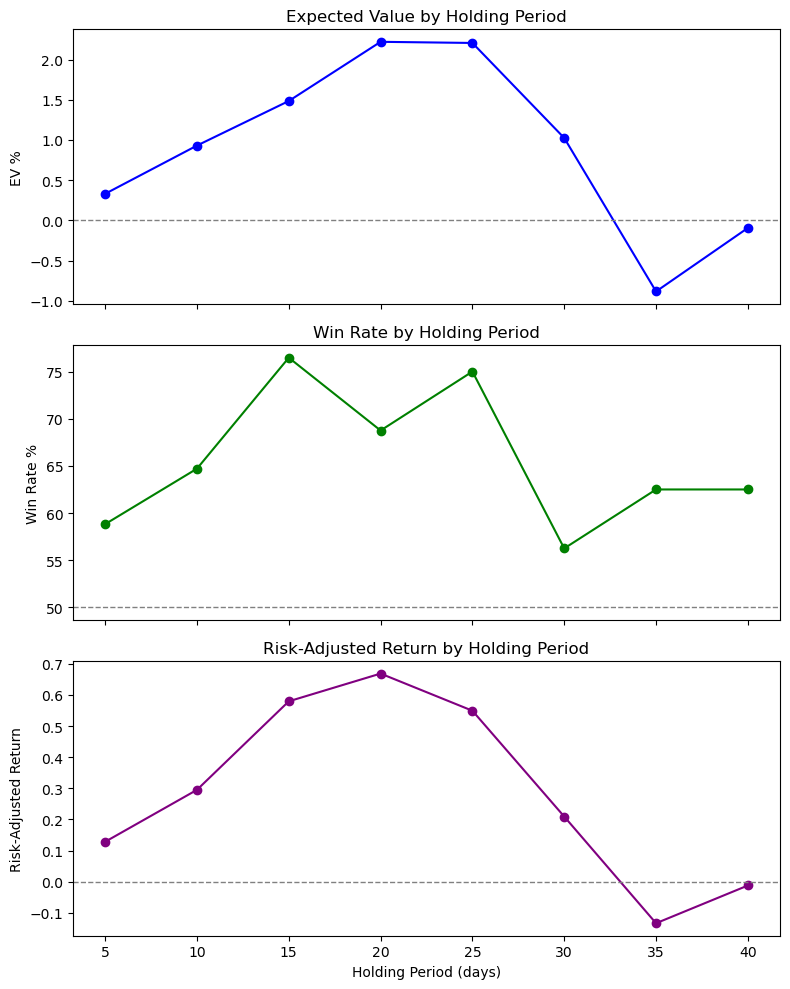

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(summary_df["holding_period"], summary_df["EV_%"], marker="o", color="blue")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_ylabel("EV %")
axes[0].set_title("Expected Value by Holding Period")

axes[1].plot(summary_df["holding_period"], summary_df["win_rate_%"], marker="o", color="green")
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("Win Rate %")
axes[1].set_title("Win Rate by Holding Period")

axes[2].plot(summary_df["holding_period"], summary_df["risk_adjusted"], marker="o", color="purple")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[2].set_ylabel("Risk-Adjusted Return")
axes[2].set_xlabel("Holding Period (days)")
axes[2].set_title("Risk-Adjusted Return by Holding Period")

plt.tight_layout()
plt.show()

**So looking at the curves, the best holding period for this pair is between 15 to 25 days**